In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [ ]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
print("MODEL PERFORMANCE TESTING")
print(f"Accuracy Score: {accuracy_score(y_test, predictions):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nDetailed Classification Report:")
print(classification_report(y_test, predictions))

MODEL PERFORMANCE TESTING
Accuracy Score: 0.7502

Confusion Matrix:
[[749 287]
 [ 65 308]]

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



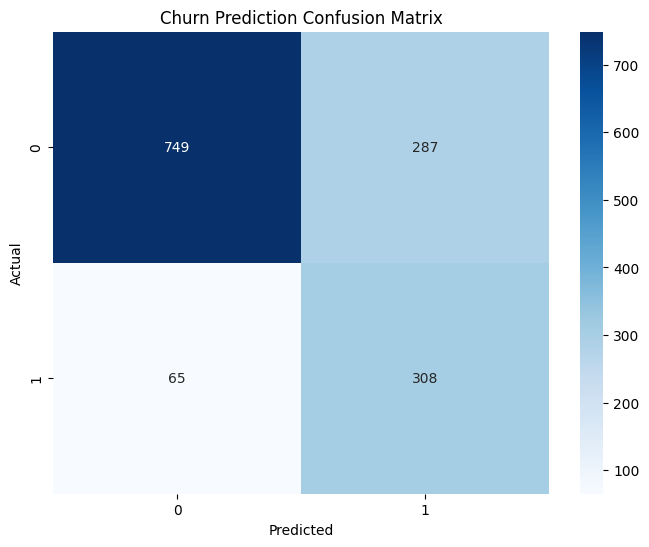

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Churn Prediction Confusion Matrix')
plt.show()

In [ ]:
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
importance = importance.sort_values(by='Coefficient', ascending=False)
print("\nTop Predictors for Churn:")
print(importance.head(5))


Top Predictors for Churn:
                           Feature  Coefficient
10     InternetService_Fiber optic     1.042098
3                     TotalCharges     0.594512
23             StreamingMovies_Yes     0.416087
28  PaymentMethod_Electronic check     0.345277
26            PaperlessBilling_Yes     0.313878


In [ ]:
joblib.dump(model, 'churn_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(X_train.columns.tolist(), 'model_columns.joblib')

print("Success: Model, Scaler, and Columns saved to disk.")

Success: Model, Scaler, and Columns saved to disk.


In [ ]:
import pandas as pd
import numpy as np
import joblib

loaded_model = joblib.load('churn_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')
model_columns = joblib.load('model_columns.joblib')

def predict_churn(customer_data):
    input_df = pd.DataFrame([customer_data])

    input_df = pd.get_dummies(input_df)

    input_df = input_df.reindex(columns=model_columns, fill_value=0)

    num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    input_df[num_cols] = loaded_scaler.transform(input_df[num_cols])

    prediction = loaded_model.predict(input_df)[0]
    probability = loaded_model.predict_proba(input_df)[0][1]

    return "CHURN (Yes)" if prediction == 1 else "STAY (No)", probability


t = int(input("Enter Tenure (months): "))
mc = float(input("Enter Monthly Charges: "))
new_customer['tenure'] = t
new_customer['MonthlyCharges'] = mc
new_customer['TotalCharges'] = t * mc
res, p = predict_churn(new_customer)
print(f"Result: {res} ({p:.2%})")

Enter Tenure (months): 5
Enter Monthly Charges: 1000
Result: STAY (No) (0.01%)
